Problema 1: Inteligencia artificial para problemas inversos

En este problema se estudiara el uso de tecnicas de inteligencia artificial para inferir parametros fısicos a partir de datos simulados. Considere un oscilador armonico amortiguado:


$m\ddot{x}+\gamma \dot{x}+kx=0$
 
con $m=1$, $x(0)=1$ y $\dot{x}(0)=0$. El objetivo es entrenar un modelo de aprendizaje
supervisado que, a partir de una señal temporal: 

$\mathbf{x}=(x(t_{1}), x(t_{2}),..., x(t_{N_{t}}))$ 

prediga los parametros fısicos $\theta=(\gamma, k)$.

a) Explique con sus palabras y/o con las ecuaciones correspondientes los siguientes conceptos:

1) Problema directo e inverso: si en el problema directo se conocen $(\gamma, k)$ y se calcula
$x(t)$ ¿cual es la dificultad del problema inverso? 

Si en el problema directo conocemos $(\gamma, k)$, los parametros fisicos del sistema y con ellos se calcula $x(t)$, el problema inverso consiste en partir de una señal dada $x(t)$ y encontrar los parametros fisicos que la generaron. Luego, la dificultad de este tipo de problemas radica en que la relacion entre los parametros y la señal puede ser no lineal o ser afectada por ruido. 

2) Aprendizaje supervisado: si tenemos un conjunto de datos de entrada y salida ${(\mathbf{x}_{i}, \theta_{i})}_{i=1}^{N}$, donde $\mathbf{x}_{i}$ es la señal observada y $\theta_{i}=(\gamma_{i}, k_{i})$ son las etiquetas, ¿es necesario conocer
las etiquetas para un problema inverso? 

El aprendizaje supervisado consiste en entrenar un modelo utilizando pares de entrada y salida que sean conocidos, por tanto si necesitamos conocer las etiquetas durante el entrenamiento ya que el modelo aprende en base a comparacion de valores predichos con valores reales.

3) Conjuntos de entrenamiento y validacion: explique por que se separan los datos en train y test. 

Se separan porque el primer conjunto se utiliza para ajustar los parametros internos del modelo utilizado y el segundo conjuntopermite evaluar la capacidad del modelo de predecir correctamente sobre datos nuevos.

4) Funcion de perdida: explique por que es necesario definir un error cuadratico medio, por ejemplo: 

$MSE=\frac{1}{N}\sum_{i}^{N} [(\gamma_{i} - \hat{\gamma}_{i})^{2} + (k_{i}-\hat{k}_{i})^{2}]$

Es necesario porque necesitamos una metrica que nos diga que tan bien predice el modelo para asi poder ajustarlo a un error maximo sobre el cual se guiara para el entrenamiento. 

b) Genere un conjunto de datos simulados con $N=3000$ señales. Para cada señal, escoja aleatoriamente los parametros fısicos $\gamma$ y $k$ desde distribuciones uniformes: 

$\gamma \thicksim \mathcal{U}(0.05, 1.0), \qquad k \thicksim \mathcal{U}(1.0, 5.0)$ 

La notacion $\mathcal{U}(a, b)$ representa una distribucion uniforme en el intervalo $[a, b]$. Para cada par $(\gamma, k)$, resuelva la ecuacion diferencial en el intervalo $t\in [0, 10]$ usando $N_{t}=1000$ puntos. Luego agregue ruido gaussiano independiente a cada punto de la señal: 

$x_{\textit{obs}}(t_{j})=x(t_{j}) + \eta_{j}, \qquad \eta_{j} \thicksim \mathcal{N}(0, \sigma^{2})$ 

con $\sigma=0.02$. La notacion $\eta_{j} \thicksim \mathcal{N}(0, \sigma^{2})$ significa que cada $\eta_{j}$ es un numero aleatorio extraido desde una distribucion normal, o gaussiana, de media cero y varianza $\sigma^{2}$. En este caso, $\sigma$ controla la intensidad del ruido experimental agregado a la señal. Grafique algunas señales generadas y discuta como cambian la frecuencia y el decaimiento al variar $k$ y $\gamma$. 

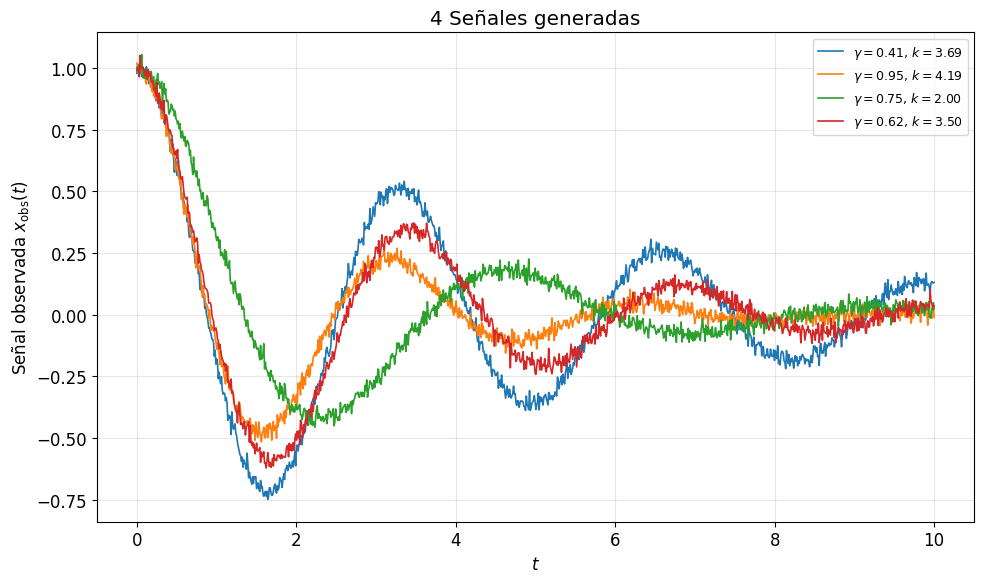

In [2]:
#############################################
#                 Librerias                 #
#############################################

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

plt.rcParams.update({                                     #Estilo de graficas
    "figure.figsize": (10, 6),
    "font.size": 12,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "figure.dpi": 100,
})

np.random.seed(42)                                        #Esto es para que cada vez que corramos el codigo obtengamos los mismo resultados

#############################################
#               Partametros                 #
#############################################

m=1.0                                                     #Masa
N=3000                                                    #Numero de señales
Nt=1000                                                   #Numero de puntos temporales en el intervalo de integracion
sigma=0.02                                                #Intensidad del ruido experimental
t_0=0                                                     #Tiempo inicial
t_f=10                                                    #Tiempo final
t_eval=np.linspace(t_0, t_f, Nt)                          #Arreglo de tiempos de integracion con numero de pasos temporales

#Condiciones iniciales

x0=1                                                      #Posicion inicial
v0=0                                                      #Velocidad inicial
y0=[x0, v0]                                               #Condiciones inciales del problema

#############################################
#      Oscilador Armonico Amortiguado       #
#############################################

def OAA(t, y, gamma, k):
    x, v=y                                                #Para arreglo de solucion
    dxdt=v                                                #Definicion de velocidad
    dvdt= -(gamma/m)*v-(k/m)*x                            #Ecuacion diferencial para Oscilador Armonico Amortiguado

    return [dxdt, dvdt]                                   #Devuelve ecuacion diferencial en algun tiempo

#Funcion para generar la señal

def GS(gamma, k, sigma):
    sol=solve_ivp(fun=lambda t, y: OAA(t, y, gamma, k), t_span=(t_0, t_f), y0=y0, t_eval=t_eval, method="RK45")      #Obtengo solucion con el integrador Solve_ivp con el metodo RK45
    x=sol.y[0]
    ruido_exp=np.random.normal(loc=0.0, scale=sigma, size=Nt)         #Distribucion normal con media nula, desviacion estadar sigma y de tamaño N_t
    x_obs=x+ruido_exp                                     #Genero señal observada con ruido experimental

    return x_obs

#############################################
#                  Data-set                 #
#############################################    

#Parametros

gammas=np.random.uniform(0.05, 1.0, N)                    #Genero los gammas en base a una distribucion uniforme aleatoria
ks=np.random.uniform(1.0, 5.0, N)                         #Genero los k en base a una distribucion uniforme
MS=np.zeros((N, Nt))                                      #Creo una matriz que contendra en cada fila una señal
theta=np.zeros((N, 2))                                    #Genero matriz que contendra en cada fila gamma y k correspondiente

for i in range(N):                                        #Ciclo que recorre todas las señales
    gamma_i=gammas[i]                                     #Para cada señal se asigna un gamma
    k_i=ks[i]                                             #Para cada señal se asigna un k
    MS[i, :]=GS(gamma_i, k_i, sigma)                      #Guardamos señal para cierto gamma y k
    theta[i, :]=[gamma_i, k_i]                            #Guardamos cada gamma y cada k por señal

#############################################
#       Graficas de algunas señales         #
#############################################

señales=[0, 1, 2, 3]                                      #Creo lista para tomar 4 señales

plt.figure(figsize=(10, 6))

for i in señales:
    gamma_i, k_i=theta[i]                                 #Tomo el gamma y k de la primera señal guardada
    plt.plot(t_eval, MS[i], lw=1.2, label=fr"$\gamma={gamma_i:.2f}$, $k={k_i:.2f}$")         #Ploteo la señal en cuestion

plt.xlabel("$t$")
plt.ylabel(r"Señal observada $x_{\mathrm{obs}}(t)$")
plt.title("4 Señales generadas")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

Notemos que para parametros de amortiguamiento cada vez mayores la señal comienza a decaer mas rapidamente, disminuyendo su amplitud conforme pasa el tiempo. Ademas, notemos que mientras el parametro asociada a la constante elastica del resorte $k$ es mayor la señal oscila mas rapido, es decir, su frecuencia es mayor.

c) Separe los datos en 80% para entrenamiento y 20% para validacion. Entrene dos modelos de regresion, por ejemplo:

RandomForestRegressor 
MLPRegressor o una red neuronal simple en PyTorch 

Reporte el desempeño de cada modelo usando:

$RMSE_{\gamma}= \sqrt{\frac{1}{N_{test}}\sum_{i=1}^{N_{test}}(\gamma_{i}-\hat{\gamma}_{i})^{2}}, \qquad RMSE_{k}=\sqrt{\frac{1}{N_{test}}\sum_{i=1}^{N_{test}}(k_{i}-\hat{k}_{i})^{2}}$

Los modelos que utilizare RandomForestRegressor y MLPRegressor.


In [5]:
#############################################
#    Separacion de entrenamiento y test     #
#############################################

from sklearn.model_selection import train_test_split

MSentrenado, MStesteo, thetaentrenamiento, thetatesteo=train_test_split(MS, theta, test_size=0.2, random_state=42)    #La funcion nos entrega los datos apra testeo y para entrenamiento, dividiendolo en 20% y 80%, respectivamente.

#############################################
#        Errores cuadraticos medios         #
#############################################

from sklearn.metrics import mean_squared_error                   #Metrica

def RMSE(theta_dato, theta_prediccion):
    RMSE_gamma=np.sqrt(mean_squared_error(theta_dato[:, 0], theta_prediccion[:, 0]))             #Error cuadratico medio de gamma
    RMSE_k=np.sqrt(mean_squared_error(theta_dato[:, 1], theta_prediccion[:, 1]))                 #Error cuadratico medio de k
    
    return RMSE_gamma, RMSE_k

#############################################
#               Random Forest               #
#############################################

from sklearn.ensemble import RandomForestRegressor

MRF=RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)                     #Modelo Random Forest 
MRF.fit(MSentrenado, thetaentrenamiento)                                                    #Entrenamiento
thetapredRF=MRF.predict(MStesteo)                                                           #Predicciones por Random Forest
RMSEgammaRF, RMSEkRF= RMSE(thetatesteo, thetapredRF)                                        #Calculo errores cuadraticos medios

print("Random Forest Regressor")
print(f"RMSE_gamma = {RMSEgammaRF:.5f}")
print(f"RMSE_k     = {RMSEkRF:.5f}")

#############################################
#                    MLP                    #
#############################################

from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor

scaler=StandardScaler()
MSentrenadoaescala=scaler.fit_transform(MSentrenado)
MStesteoaescala=scaler.transform(MStesteo)

MLP=MLPRegressor(hidden_layer_sizes=(128, 64), activation="relu", solver="adam", max_iter=300, random_state=42, early_stopping=True)
MLP.fit(MSentrenadoaescala, thetaentrenamiento)

PredicthetaMLP=MLP.predict(MStesteoaescala)

RMSEgammaMLP, RMSEkMLP=RMSE(thetatesteo, PredicthetaMLP)

print("MLPRegressor")
print(f"RMSE_gamma = {RMSEgammaMLP:.5f}")
print(f"RMSE_k     = {RMSEkMLP:.5f}")

Random Forest Regressor
RMSE_gamma = 0.01602
RMSE_k     = 0.17109
MLPRegressor
RMSE_gamma = 0.09448
RMSE_k     = 0.13220


d) Estudie el efecto del ruido repitiendo el entrenamiento para:

$\sigma = 0, 0.01, 0.02, 0.05, 0.1$

Grafique $RMSE_{\gamma}$ y $RMSE_{k}$ como funcion de $\sigma$. Discuta que parametro es mas dificil de inferir y como se manifiesta el sobreajuste cuando el error de entrenamiento es pequeño pero el error de validacion es grande. 

Queremos generar datasets con distintos ruidos, para ello utilizaremos Random Forest ya que presento mejores desempeños:

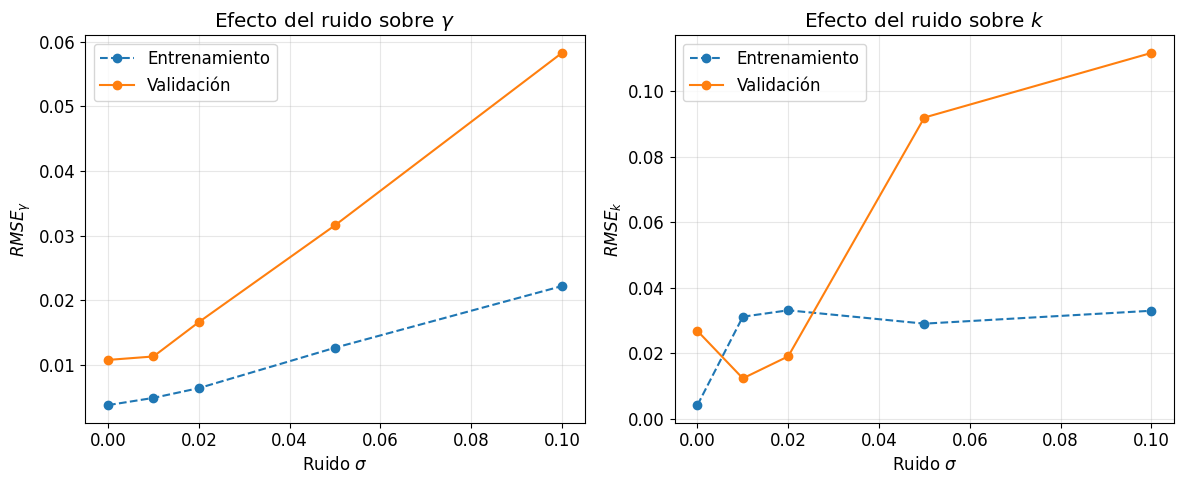

In [6]:
#############################################
#         Generacion de datasets            #
#############################################

def GDR(N, sigmas):
    gammas=np.random.uniform(0.05, 1.0, N)                    #Utilizo las mismas definiciones de los parametros
    ks=np.random.uniform(1.0, 5.0, N)                        
    MS=np.zeros((N, Nt))                                      
    theta=np.zeros((N, 2))          
    for j in range(N):
        gamma_j=gammas[j]
        k_j=ks[j]
        MS[j, :]=GS(gamma_j, k_j, sigmas)  
        theta[j, :]=[gamma_j, k_j]

    return MS, theta

sigmas=[0, 0.01, 0.02, 0.05, 0.1]

RMSEgammaentrenar=[]
RMSEkentrenar=[]
RMSEgammatesteo=[]
RMSEktesteo=[]

for i in sigmas:
    Dataruido, thetaruido=GDR(N, i)
    Dataentrenamiento, Datatesteo, thetaentrenada, thetatesteo= train_test_split(Dataruido, thetaruido, test_size=0.2, random_state=42)
    MRF=RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    MRF.fit(Dataentrenamiento, thetaentrenada)

    thetapredentrenada=MRF.predict(Dataentrenamiento)
    thetapredtesteo=MRF.predict(Datatesteo)
    RMSEgammatrain, RMSEktrain=RMSE(thetaentrenada, thetapredentrenada)
    RMSEgammatest, RMSEktest=RMSE(thetatesteo, thetapredtesteo)

    RMSEgammaentrenar.append(RMSEgammatrain)
    RMSEkentrenar.append(RMSEktrain)
    RMSEgammatesteo.append(RMSEgammatest)
    RMSEktesteo.append(RMSEktest)

#############################################
#                Graficas                   #
#############################################

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(sigmas, RMSEgammaentrenar, "o--", label="Entrenamiento")
axes[0].plot(sigmas, RMSEgammatesteo, "o-", label="Validación")
axes[0].set_xlabel(r"Ruido $\sigma$")
axes[0].set_ylabel(r"$RMSE_{\gamma}$")
axes[0].set_title(r"Efecto del ruido sobre $\gamma$")
axes[0].legend()

axes[1].plot(sigmas, RMSEkentrenar, "o--", label="Entrenamiento")
axes[1].plot(sigmas, RMSEktesteo, "o-", label="Validación")
axes[1].set_xlabel(r"Ruido $\sigma$")
axes[1].set_ylabel(r"$RMSE_k$")
axes[1].set_title(r"Efecto del ruido sobre $k$")
axes[1].legend()

plt.tight_layout()
plt.show()

A partir de la grafico notamos que el aumento del ruido experimental afecta la capacidad del modelo para obtener los parametros de amortiguamiento y constante elatica, por lo que la presencia de perturbaciones externas en la señal dificulta la reconstruccion de los parametros en cuestion.

Para el parametro $\gamma$ el error de entrenamiento y el de validacion aumentan de forma monotona clara a partir de $\sigma=0.01$. Sin embargo, el error de validacion se vuelve cada vez mas grande en comparacion al de entrenamiento, lo que se interpreta como que el modelo en cuestion generaliza de peor manera a mayor ruido. 

Por otro lado, para el parametro $k$, el comportamiento es mucho mas variable para ruidos pequeños. Notemos que para $\sigma=0.01$ el error de validacion decrece para posteriormente aumentar y superar con creces al error de entrenamiento, donde este ultimo se mantiene relativamente constante. Por lo cual, tenemos que la estimacion de $k$ tambien deteriora con una presencia mayor de ruido.

Entonces, de acuerdo a los resultados obtenidos, el parametro mas dificil de inferir es $k$, ya que presenta errores de validacion mas grande que $\gamma$. Finalmente, el sobreajuste aparece cuando el error de entrenamiento permanece por debajo del error de validacion de manera considerable. En estos casos el modelo aprende muy bien el conjunto de entrenamiento, pero pierde su capacidad de evaluar de manera correcta datos de testeo. En nuestros resultados esto sucede cuando los valores del ruido son cada vez mas grandes.